## *------------------------------- ~ CUSTOMER SHOPPING TRENDS ANALYSIS ~ -------------------------------*

### ~ *Project Overview ~*

This project presents a comprehensive Exploratory Data Analysis (EDA) of customer shopping behavior using transactional and demographic data. The objective is to uncover meaningful insights that can help businesses optimize revenue, improve customer retention, and enhance overall operational efficiency.

The analysis focuses on understanding purchasing behavior, customer segmentation, revenue drivers, and the impact of marketing strategies such as discounts and subscriptions.

### *~ Objective of the Study ~*
The primary objective of this analysis is:

 - To understand customer purchasing patterns

 - To identify key revenue-driving segments

 - To analyze customer loyalty behavior

 - To evaluate the effectiveness of discounts and subscriptions

 - To uncover seasonal and category-level performance trends

This study aims to transform raw transactional data into strategic business insights

### *~ Business Goals ~*
Based on the problem statement, the key business goals are:
 - Increase overall revenue

 - Improve customer retention rate

 - Strengthen subscription adoption

 - Optimize discount allocation

 - Enhance category-level performance

 - Improve customer satisfaction (review ratings)

### *~ Importing required libraries ~*

In [18]:
# Data handling
import numpy as np                # Used for fast numerical calculations and working with arrays.
import pandas as pd               # Used for Data cleaning, manipulation, and analysis using DataFrames.   

# Data Visualizations
import matplotlib.pyplot as plt  # Used for creating basic static data visualizations like line and bar charts.
import seaborn as sns            # Used for creating advanced and visually attractive statistical plots.


import warnings                 # Imports the built-in warnings module and suppresses all warning messages during code execution.
warnings.filterwarnings('ignore') 

from tabulate import tabulate   # Imports the tabulate function to display data in a formatted table layout.

### *~ Loading dataset ~*

In [19]:
df = pd.read_csv("D:/shopping_trends.csv", encoding = 'Latin')  # pd.read_csv() => Reads CSV file into DataFrame
df.head()  # head() => Shows first 5 rows to preview data

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


### *~ Data Overview ~*

##### 1. Shape of dataset :

In [20]:
df.shape         # shape => Returns (rows, columns)

(3900, 19)

##### 2. Check Data Types :

In [21]:
df.dtypes      # dtypes shows the data type of each column in the dataset,

Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season                       object
Review Rating               float64
Subscription Status          object
Payment Method               object
Shipping Type                object
Discount Applied             object
Promo Code Used              object
Previous Purchases            int64
Preferred Payment Method     object
Frequency of Purchases       object
dtype: object

##### 3. Check Unique Values :

In [22]:
df.nunique()       # nunique() returns the number of unique values in each column

Customer ID                 3900
Age                           53
Gender                         2
Item Purchased                25
Category                       4
Purchase Amount (USD)         81
Location                      50
Size                           4
Color                         25
Season                         4
Review Rating                 26
Subscription Status            2
Payment Method                 6
Shipping Type                  6
Discount Applied               2
Promo Code Used                2
Previous Purchases            50
Preferred Payment Method       6
Frequency of Purchases         7
dtype: int64

### *~ Data Cleaning ~*

##### 1. Identify Null Values :

In [23]:
df.isnull().sum()        # isnull().sum() shows the total number of missing (null) values in each column

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

##### 2. Check Duplicates :

In [24]:
df.duplicated().sum()        # .duplicated().sum() returns the total number of duplicate rows in the dataset

np.int64(0)

##### *Conclusion*
The dataset contains **3,900 customer records and 19 variables**, making it large and reliable for analysis. It is clean, well-structured, and offers strong segmentation potential for meaningful business insights.
 

### *~ Analytical Approach ~*

### *1. KPI Identification :*

In [25]:
# Total Revenue
total_revenue = df['Purchase Amount (USD)'].sum()    # Calculated the total revenue generated by summing all purchase amounts.

# Total Orders             
total_orders = df.shape[0]      # Counted total number of orders (since each row represents one purchase).

# Average Order Value (AOV)    
aov = total_revenue / total_orders  # Measured average revenue earned per order.

# Average Previous Purchases (Repeat Indicator)      
avg_previous_purchases = df['Previous Purchases'].mean()   # Calculated the average number of past purchases per customer (repeat behavior indicator).

# Most Common Purchase Frequency     
most_common_frequency = df['Frequency of Purchases'].mode()[0]   # Identified the most frequent buying pattern.

# Subscription Conversion Rate
subscription_rate = df['Subscription Status'].value_counts(normalize=True)['Yes'] * 100   # Calculated percentage of customers who have an active subscription.

# Average Review Rating (Customer Satisfaction Score)
avg_rating = df['Review Rating'].mean()

# Discount Utilization Rate
discount_rate = df['Discount Applied'].value_counts(normalize=True)['Yes'] * 100    # Calculated the percentage of orders where a discount was applied.

# Create KPI Table
kpi_data = [
    ["Total Revenue", round(total_revenue,2)],
    ["Total Orders", total_orders],
    ["Average Order Value (AOV)", round(aov,2)],
    ["Average Previous Purchases", round(avg_previous_purchases,2)],
    ["Most Common Purchase Frequency", most_common_frequency],
    ["Subscription Conversion Rate (%)", round(subscription_rate,2)],
    ["Average Review Rating", round(avg_rating,2)],
    ["Discount Utilization Rate (%)", round(discount_rate,2)]]

print(tabulate(kpi_data, headers=["KPI Indicator", "Value"], tablefmt="fancy_grid"))

╒══════════════════════════════════╤════════════════╕
│ KPI Indicator                    │ Value          │
╞══════════════════════════════════╪════════════════╡
│ Total Revenue                    │ 233081         │
├──────────────────────────────────┼────────────────┤
│ Total Orders                     │ 3900           │
├──────────────────────────────────┼────────────────┤
│ Average Order Value (AOV)        │ 59.76          │
├──────────────────────────────────┼────────────────┤
│ Average Previous Purchases       │ 25.35          │
├──────────────────────────────────┼────────────────┤
│ Most Common Purchase Frequency   │ Every 3 Months │
├──────────────────────────────────┼────────────────┤
│ Subscription Conversion Rate (%) │ 27.0           │
├──────────────────────────────────┼────────────────┤
│ Average Review Rating            │ 3.75           │
├──────────────────────────────────┼────────────────┤
│ Discount Utilization Rate (%)    │ 43.0           │
╘═══════════════════════════

##### *Conclusion*
 - The business generated Dollar 233,081 from 3,900 orders, with a healthy Average Order Value of Dollar 59.76, indicating stable revenue per transaction.
 - Customers show strong repeat behavior (25 average previous purchases), and the most common buying cycle is every 3 months, reflecting consistent engagement.
 - However, the subscription conversion rate is moderate (27%), suggesting room to improve loyalty programs. The average review rating of 3.75 indicates generally satisfied customers but highlights an opportunity to enhance customer experience.
 - With a 43% discount utilization rate, promotions are influencing purchases but should be strategically optimized to protect margins.
 - Overall, the business demonstrates stable revenue, strong retention, and growth opportunities in subscriptions and customer satisfaction.

### *2. Univariate Analysis*

##### 1. Age Distribution :

#####  A] Create Age Groups :

In [26]:
df['Age Group'] = pd.cut(      # converts age into groups(bins)
    df['Age'],
    bins=[15, 30, 50, 65, 80],   # 6 values → 5 bins # range limits
    labels=['16-30','31-50','51-65','66-80'],
    include_lowest=True)

##### B] Percentage Distribution :

In [27]:
age_pct = (df['Age Group'].value_counts(normalize=True) * 100).round(2)  # normalize=true -> It divides each count by the total number of values.

print(tabulate(age_pct.items(), headers=["Age Group", "% Value"], tablefmt="fancy_grid"))

╒═════════════╤═══════════╕
│ Age Group   │   % Value │
╞═════════════╪═══════════╡
│ 31-50       │     37.82 │
├─────────────┼───────────┤
│ 51-65       │     28.74 │
├─────────────┼───────────┤
│ 16-30       │     24.33 │
├─────────────┼───────────┤
│ 66-80       │      9.1  │
╘═════════════╧═══════════╛


##### C] Visualization :

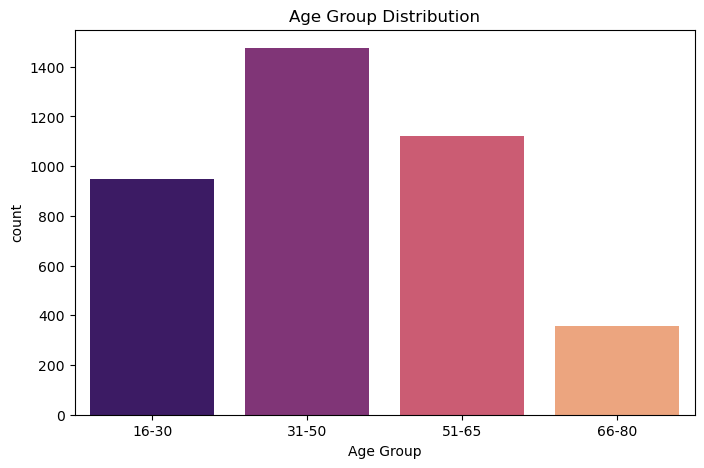

In [28]:
plt.figure(figsize=(8,5))      # Creates a new plot with width = 8 inches and height = 5 inches (controls chart size).
sns.countplot(data=df, x='Age Group', palette ='magma') #data=df:Uses your dataframe,x='Age Group':shows Age Groups on the x-axis palette='magma':Applies the magma color theme
plt.title("Age Group Distribution")
plt.show()

##### *Conclusion*
Most customers fall in the **middle-age group (from 31 - 65)** . This means the business mainly attracts adult customers rather than very young or very old customers.

##### 2. Gender Distribution :

##### A] Percentage Distribution :

In [29]:
gender_pct = (df['Gender'].value_counts(normalize=True) * 100).round(2)

print(tabulate(gender_pct.items(), headers=["Gender", "% Value"], tablefmt="fancy_grid"))

╒══════════╤═══════════╕
│ Gender   │   % Value │
╞══════════╪═══════════╡
│ Male     │        68 │
├──────────┼───────────┤
│ Female   │        32 │
╘══════════╧═══════════╛


##### B] Visualization :

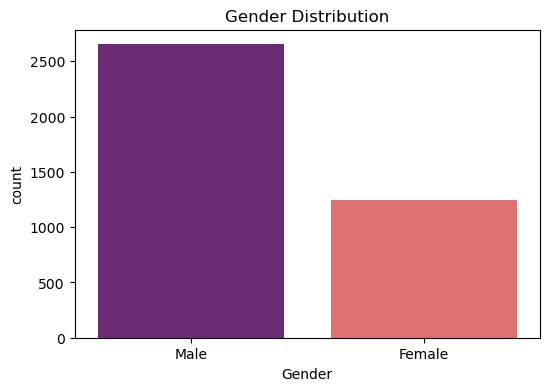

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender', palette ='magma')
plt.title("Gender Distribution")
plt.show()

##### *Conclusion*
The customer base is dominated by one gender **(mostly male in this dataset)** Marketing strategies can be adjusted to balance the customer base.


##### 3. Category Distribution :

##### A] Percentage Distribution :

In [31]:
category_pct = (df['Category'].value_counts(normalize=True) * 100).round(2)
print(tabulate(category_pct.items(), headers=["Category", "% Value"], tablefmt="fancy_grid"))

╒═════════════╤═══════════╕
│ Category    │   % Value │
╞═════════════╪═══════════╡
│ Clothing    │     44.54 │
├─────────────┼───────────┤
│ Accessories │     31.79 │
├─────────────┼───────────┤
│ Footwear    │     15.36 │
├─────────────┼───────────┤
│ Outerwear   │      8.31 │
╘═════════════╧═══════════╛


##### B] Visualization :

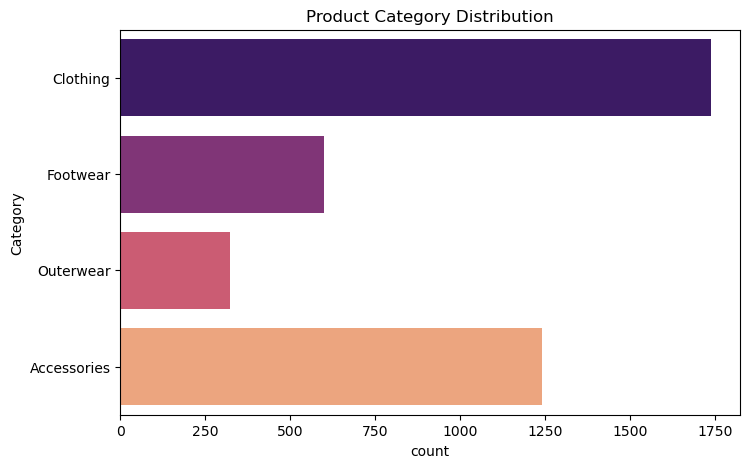

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, y='Category', palette='magma')
plt.title("Product Category Distribution")
plt.show()

##### *Conclusion*
**Clothing** category leads in purchases, making it the core revenue-driving segment.

##### 4. Season Distribution :

##### A] Percentage Distribution :

In [33]:
season_pct = (df['Season'].value_counts(normalize=True) * 100).round(2)
print(tabulate(season_pct.items(), headers=["Season", "% Value"], tablefmt="fancy_grid"))

╒══════════╤═══════════╕
│ Season   │   % Value │
╞══════════╪═══════════╡
│ Spring   │     25.62 │
├──────────┼───────────┤
│ Fall     │     25    │
├──────────┼───────────┤
│ Winter   │     24.9  │
├──────────┼───────────┤
│ Summer   │     24.49 │
╘══════════╧═══════════╛


##### B] Visualization :

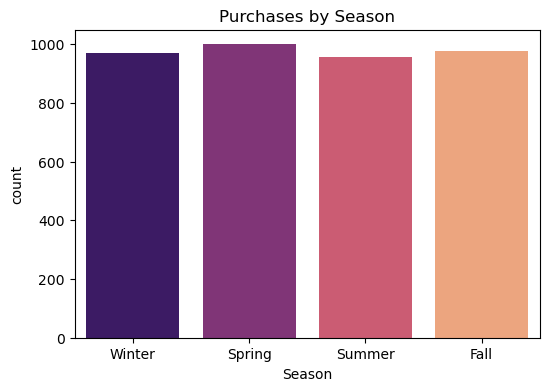

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Season', palette='magma')
plt.title("Purchases by Season")
plt.show()

##### *Conclusion*
Purchases are fairly consistent across all seasons, with **Spring slightly leading** and **Summer slightly lower** than the others.

##### 5. Review Rating Distribution :

##### A] Creating Rating Groups :

In [35]:
df['Rating Group'] = pd.cut(
    df['Review Rating'],
    bins=[2.4, 3.4, 4.2, 5.0],   # 3 groups
    labels=['Low (2.5-3.4)','Moderate (3.5-4.2)','High (4.3-5.0)'],
    include_lowest=True)

##### B] Percentage Distribution :

In [36]:
rating_pct = (df['Rating Group'].value_counts(normalize=True) * 100).round(2)
print(tabulate(rating_pct.items(), headers=["Rating Group", "% Value"], tablefmt="fancy_grid"))

╒════════════════════╤═══════════╕
│ Rating Group       │   % Value │
╞════════════════════╪═══════════╡
│ Low (2.5-3.4)      │     38.21 │
├────────────────────┼───────────┤
│ Moderate (3.5-4.2) │     32.46 │
├────────────────────┼───────────┤
│ High (4.3-5.0)     │     29.33 │
╘════════════════════╧═══════════╛


##### B] Visualization :

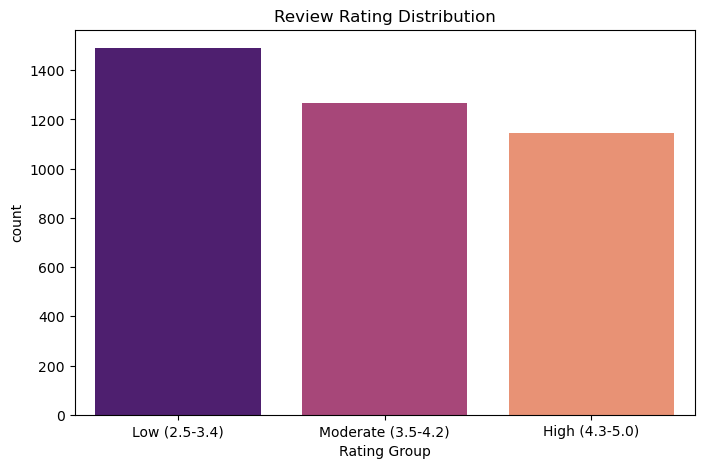

In [37]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Rating Group', palette='magma')
plt.title("Review Rating Distribution")
plt.show()

##### *Conclusion*
 - The **Low rating group (2.5–3.4)** has the **highest number of customers**, indicating a noticeable portion of customers are not fully satisfied.
 - The **Moderate satisfaction group (3.5–4.2)** also represents a **large share**, showing average but improvable customer experience.
 - The **High satisfaction group (4.3–5.0)** is **slightly lower** compared to others, suggesting there is room to increase highly satisfied customers.

##### 6. Subscription Status :

##### A] Percentage Distribution :

In [38]:
subscription_pct = (df['Subscription Status'].value_counts(normalize=True) * 100).round(2)
print(tabulate(subscription_pct.items(), headers=["Subscription", "% Value"], tablefmt="fancy_grid"))

╒════════════════╤═══════════╕
│ Subscription   │   % Value │
╞════════════════╪═══════════╡
│ No             │        73 │
├────────────────┼───────────┤
│ Yes            │        27 │
╘════════════════╧═══════════╛


##### B] Visualization :

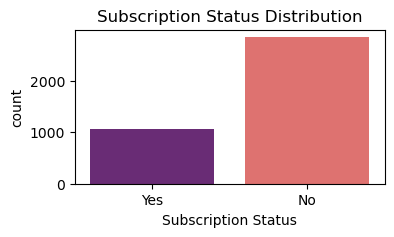

In [39]:
plt.figure(figsize=(4,2))
sns.countplot(data=df, x='Subscription Status',palette='magma' )
plt.title("Subscription Status Distribution")
plt.show()

##### *Conclusion*
The majority of customers are **non-subscribers**, significantly outnumbering those with a subscription.

##### 7. Location Distribution :

##### A] Percentage Distribution :

In [40]:
location_pct = (df['Location'].value_counts(normalize=True) * 100).round(2)
print(tabulate(location_pct.items(), headers=["Location", "% Value"], tablefmt="fancy_grid"))

╒════════════════╤═══════════╕
│ Location       │   % Value │
╞════════════════╪═══════════╡
│ Montana        │      2.46 │
├────────────────┼───────────┤
│ California     │      2.44 │
├────────────────┼───────────┤
│ Idaho          │      2.38 │
├────────────────┼───────────┤
│ Illinois       │      2.36 │
├────────────────┼───────────┤
│ Alabama        │      2.28 │
├────────────────┼───────────┤
│ Minnesota      │      2.26 │
├────────────────┼───────────┤
│ Nebraska       │      2.23 │
├────────────────┼───────────┤
│ New York       │      2.23 │
├────────────────┼───────────┤
│ Nevada         │      2.23 │
├────────────────┼───────────┤
│ Maryland       │      2.21 │
├────────────────┼───────────┤
│ Delaware       │      2.21 │
├────────────────┼───────────┤
│ Vermont        │      2.18 │
├────────────────┼───────────┤
│ Louisiana      │      2.15 │
├────────────────┼───────────┤
│ North Dakota   │      2.13 │
├────────────────┼───────────┤
│ Missouri       │      2.08 │
├───────

#### B] Visualization :

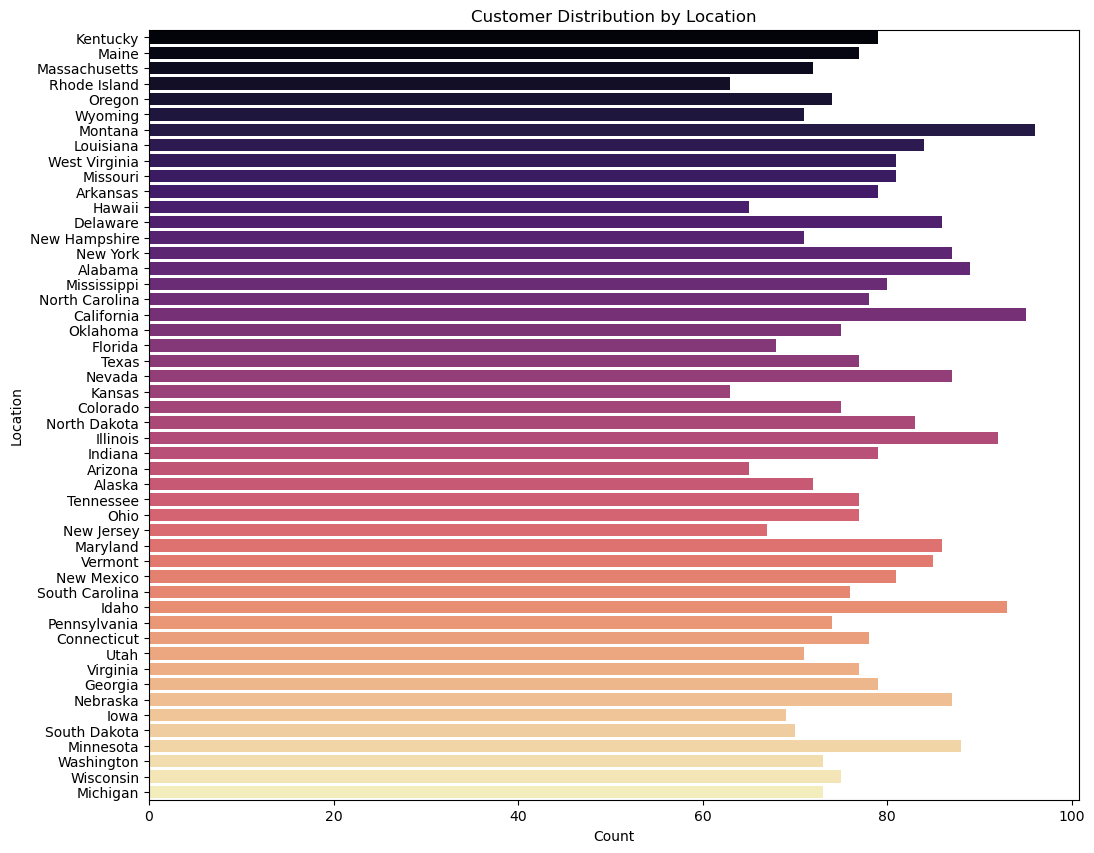

In [41]:
plt.figure(figsize=(12,10))
sns.countplot(data=df, y='Location', palette='magma')
plt.title("Customer Distribution by Location")
plt.xlabel("Count")
plt.ylabel("Location")
plt.show()

##### *Conclusion*
Certain locations like States like **Montana, California, Idaho, Illinois, and Alabama** show comparatively higher customer counts, indicating stronger customer concentration in these locations.


##### 8. Size Distribution :

##### A] Percentage Distribution :

In [42]:
size_pct = (df['Size'].value_counts(normalize=True) * 100).round(2)
print(tabulate(size_pct.items(), headers=["Size", "% Value"], tablefmt="fancy_grid"))

╒════════╤═══════════╕
│ Size   │   % Value │
╞════════╪═══════════╡
│ M      │        45 │
├────────┼───────────┤
│ L      │        27 │
├────────┼───────────┤
│ S      │        17 │
├────────┼───────────┤
│ XL     │        11 │
╘════════╧═══════════╛


##### B] Visualization :

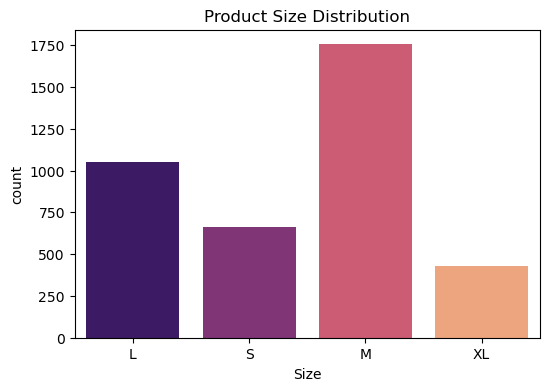

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Size',  palette='magma' )
plt.title("Product Size Distribution")
plt.show()

##### *Conclusion*
Product size **M is the most popular**, followed by L, while S and XL have significantly lower demand, indicating a strong preference for medium-sized products.

##### 9. Payment Method Distribution :

##### A] Percentage Distribution :

In [44]:
payment_pct = (df['Payment Method'].value_counts(normalize=True) * 100).round(2)
print(tabulate(payment_pct.items(), headers=["Payment", "% Value"], tablefmt="fancy_grid"))

╒═══════════════╤═══════════╕
│ Payment       │   % Value │
╞═══════════════╪═══════════╡
│ Credit Card   │     17.85 │
├───────────────┼───────────┤
│ Venmo         │     16.74 │
├───────────────┼───────────┤
│ Cash          │     16.62 │
├───────────────┼───────────┤
│ PayPal        │     16.36 │
├───────────────┼───────────┤
│ Debit Card    │     16.23 │
├───────────────┼───────────┤
│ Bank Transfer │     16.21 │
╘═══════════════╧═══════════╛


##### B] Visualization :

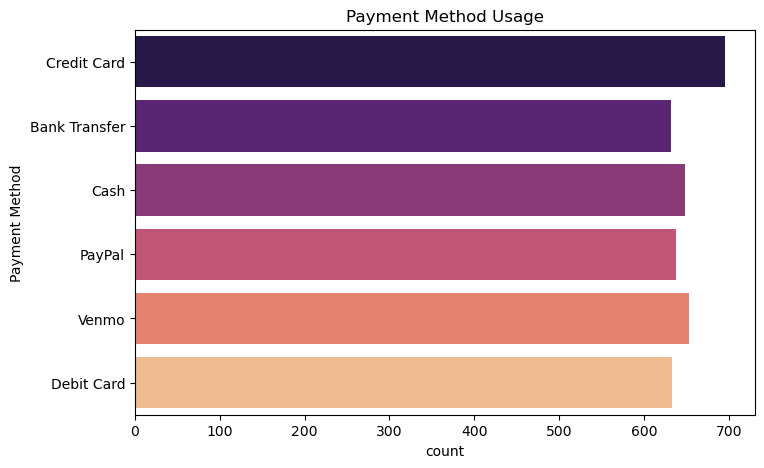

In [45]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, y='Payment Method', palette='magma')
plt.title("Payment Method Usage")
plt.show()

##### *Conclusion*
**Credit Card** is the most preferred payment method, while the other methods (Venmo, Cash, PayPal, Bank Transfer, and Debit Card) show fairly similar usage with only slight differences in customer preference.

##### 10. Shipping Type Distribution :

##### A] Percentage Distribution :

In [46]:
shipping_pct = (df['Shipping Type'].value_counts(normalize=True) * 100).round(2)
print(tabulate(shipping_pct.items(), headers=["Shipping", "% Value"], tablefmt="fancy_grid"))

╒════════════════╤═══════════╕
│ Shipping       │   % Value │
╞════════════════╪═══════════╡
│ Free Shipping  │     17.31 │
├────────────────┼───────────┤
│ Standard       │     16.77 │
├────────────────┼───────────┤
│ Store Pickup   │     16.67 │
├────────────────┼───────────┤
│ Next Day Air   │     16.62 │
├────────────────┼───────────┤
│ Express        │     16.56 │
├────────────────┼───────────┤
│ 2-Day Shipping │     16.08 │
╘════════════════╧═══════════╛


##### B] Visualization :

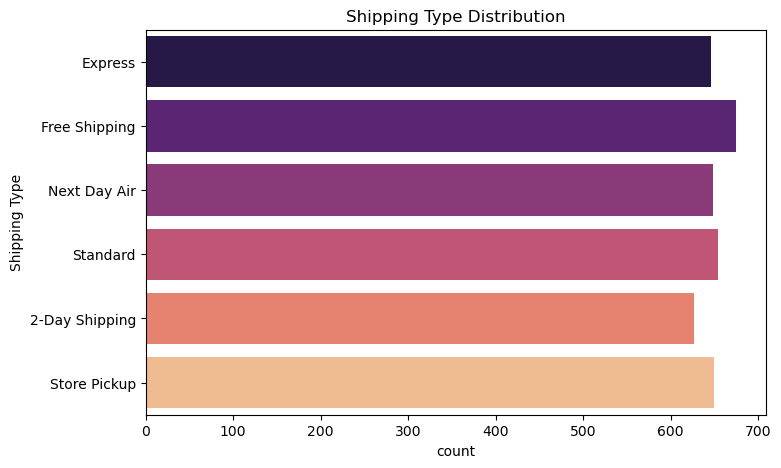

In [47]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, y='Shipping Type',palette='magma')
plt.title("Shipping Type Distribution")
plt.show()

##### *Conclusion*
Shipping preferences are fairly evenly distributed, with **Free Shipping slightly leading**, while 2-Day Shipping shows the lowest usage among the available options.

##### 11. Discount Applied :

##### A] Percentage Distribution :

In [48]:
discount_pct = (df['Discount Applied'].value_counts(normalize=True) * 100).round(2)
print(tabulate(discount_pct.items(), headers=["Discount", "% Value"], tablefmt="fancy_grid"))

╒════════════╤═══════════╕
│ Discount   │   % Value │
╞════════════╪═══════════╡
│ No         │        57 │
├────────────┼───────────┤
│ Yes        │        43 │
╘════════════╧═══════════╛


##### B] Visualization :

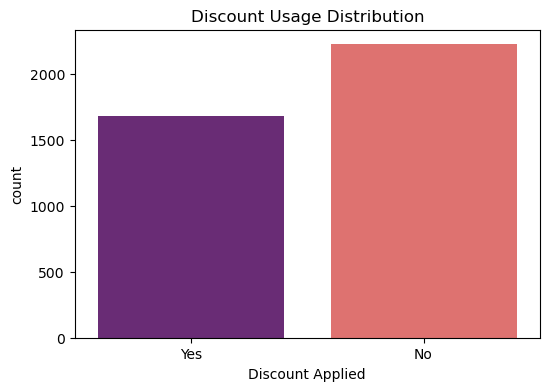

In [49]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Discount Applied',palette='magma' )
plt.title("Discount Usage Distribution")
plt.show()

##### *Conclusion*
Most purchases were made **without a discount**, indicating that a larger portion of customers buy at full price compared to those using discounts.

##### 12. Frequency of Purchases :

##### A] Percentage Distribution :

In [50]:
frequency_pct = (df['Frequency of Purchases'].value_counts(normalize=True) * 100).round(2)
print(tabulate(frequency_pct.items(), headers=["Frequency", "% Value"], tablefmt="fancy_grid"))

╒════════════════╤═══════════╕
│ Frequency      │   % Value │
╞════════════════╪═══════════╡
│ Every 3 Months │     14.97 │
├────────────────┼───────────┤
│ Annually       │     14.67 │
├────────────────┼───────────┤
│ Quarterly      │     14.44 │
├────────────────┼───────────┤
│ Monthly        │     14.18 │
├────────────────┼───────────┤
│ Bi-Weekly      │     14.03 │
├────────────────┼───────────┤
│ Fortnightly    │     13.9  │
├────────────────┼───────────┤
│ Weekly         │     13.82 │
╘════════════════╧═══════════╛


##### B] Visualization :

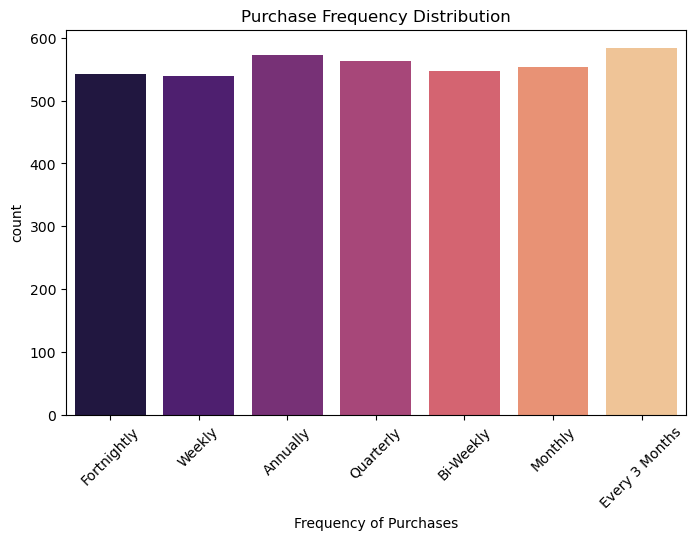

In [51]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Frequency of Purchases', palette='magma')
plt.xticks(rotation=45)
plt.title("Purchase Frequency Distribution")
plt.show()

##### *Conclusion*
Purchase frequency is fairly evenly distributed, with **Every 3 Months** and **Annually** slightly higher, indicating no strong dominance of any single buying pattern.

### *3. Bivariate Analysis*

##### 1. Category vs Revenue :

##### A] Revenue Calculation :

In [55]:
category_revenue = df.groupby('Category')['Purchase Amount (USD)'].sum()
category_revenue_df = category_revenue.reset_index() # reset_index() → Sirf data ko proper DataFrame format me convert karta hai.
                                                     # Matlab index ko normal column bana deta hai.Bas structure theek karta hai, design nahi..
category_revenue_df.columns = ["Category", "Total Revenue (USD)"]

print(tabulate(category_revenue_df,headers="keys",tablefmt="fancy_grid", showindex=False))

╒═════════════╤═══════════════════════╕
│ Category    │   Total Revenue (USD) │
╞═════════════╪═══════════════════════╡
│ Accessories │                 74200 │
├─────────────┼───────────────────────┤
│ Clothing    │                104264 │
├─────────────┼───────────────────────┤
│ Footwear    │                 36093 │
├─────────────┼───────────────────────┤
│ Outerwear   │                 18524 │
╘═════════════╧═══════════════════════╛


##### B] Visualization :

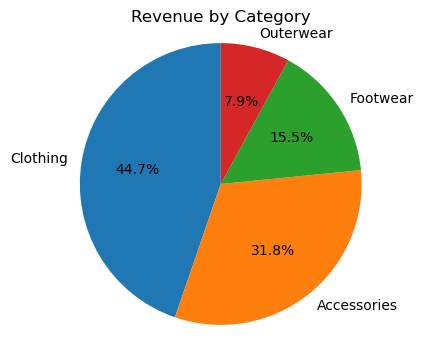

In [72]:
plt.figure(figsize=(4, 4))  # Creates a new plot with width = 4 inches and height = 4 inches.
plt.pie(category_revenue.values, labels=category_revenue.index, autopct='%1.1f%%', startangle=90) # autopct='%1.1f%%': Shows percentage on each slice (1 decimal place).
plt.title("Revenue by Category")
plt.axis('equal')  # Makes the pie a perfect circle

plt.show()

##### *Conclusion*
**Clothing** generates the **highest revenue (44.7%)**, followed by Accessories (31.8%), while **Outerwear** contributes the **least (7.9%)** to total revenue.

##### 2. Gender vs Average Purchase Amount :

##### A] Calculation :

In [56]:
# Calculate average purchase by gender
gender_avg = df.groupby('Gender')['Purchase Amount (USD)'].mean().round(2)

#  Convert to DataFrame
gender_df = gender_avg.reset_index()
gender_df.columns = ["Gender", "Average Purchase (USD)"]

# Tabulate properly
print(tabulate(gender_df,
               headers="keys",
               tablefmt="fancy_grid",
               showindex=False))

╒══════════╤══════════════════════════╕
│ Gender   │   Average Purchase (USD) │
╞══════════╪══════════════════════════╡
│ Female   │                    60.25 │
├──────────┼──────────────────────────┤
│ Male     │                    59.54 │
╘══════════╧══════════════════════════╛


##### B] Visualization :

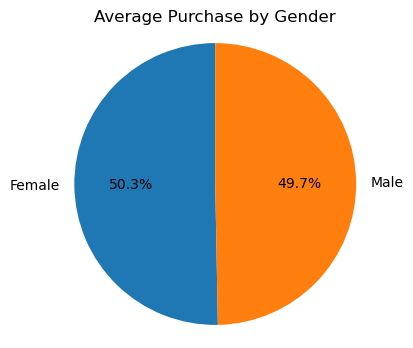

In [57]:
plt.figure(figsize=(4, 4))

plt.pie(gender_avg.values,labels=gender_avg.index,autopct='%1.1f%%',startangle=90)

plt.title("Average Purchase by Gender")
plt.axis('equal')  # Keeps pie circular

plt.show()

##### *Conclusion*
Average purchases are nearly evenly split by gender, with **females **contributing **slightly more (50.3%)** than males (49.7%).

##### 3. Subscription Status vs Revenue :

##### A] Calculation :

In [58]:
# Calculate mean revenue by subscription
subscription_revenue = (
    df.groupby('Subscription Status')['Purchase Amount (USD)'].mean().round(2))

# Convert to DataFrame
subscription_df = subscription_revenue.reset_index()
subscription_df.columns = ["Subscription Status", "Average Purchase (USD)"]

# Print formatted table
print(tabulate(subscription_df,headers="keys",tablefmt="fancy_grid",showindex=False))

╒═══════════════════════╤══════════════════════════╕
│ Subscription Status   │   Average Purchase (USD) │
╞═══════════════════════╪══════════════════════════╡
│ No                    │                    59.87 │
├───────────────────────┼──────────────────────────┤
│ Yes                   │                    59.49 │
╘═══════════════════════╧══════════════════════════╛


##### B] Visualization :

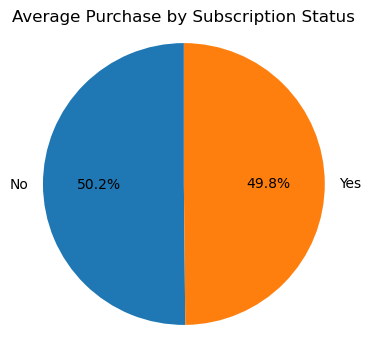

In [59]:
plt.figure(figsize=(4, 4))

plt.pie(subscription_revenue.values,labels=subscription_revenue.index,autopct='%1.1f%%',startangle=90)

plt.title("Average Purchase by Subscription Status")
plt.axis('equal')  # Keeps it circular

plt.show()

##### *Conclusion*
Average purchases are almost evenly distributed by subscription status, **with non-subscribers slightly higher (50.2%)** than subscribers (49.8%).

##### 4. Season vs Revenue :

##### A] Calculation :

In [60]:
# Calculate total revenue by season
season_revenue = (
    df.groupby('Season')['Purchase Amount (USD)'].sum().round(2))

# Convert to DataFrame
season_df = season_revenue.reset_index()
season_df.columns = ["Season", "Total Revenue (USD)"]

# Print formatted table
print(tabulate(season_df,headers="keys",tablefmt="fancy_grid",showindex=False))

╒══════════╤═══════════════════════╕
│ Season   │   Total Revenue (USD) │
╞══════════╪═══════════════════════╡
│ Fall     │                 60018 │
├──────────┼───────────────────────┤
│ Spring   │                 58679 │
├──────────┼───────────────────────┤
│ Summer   │                 55777 │
├──────────┼───────────────────────┤
│ Winter   │                 58607 │
╘══════════╧═══════════════════════╛


##### B] Visualization :

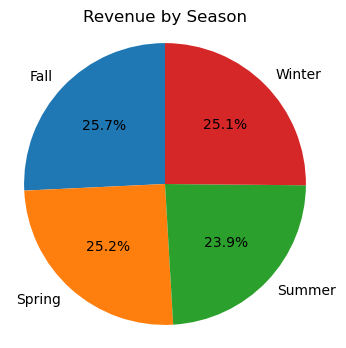

In [61]:
plt.figure(figsize=(4, 4))

plt.pie(season_revenue.values,labels=season_revenue.index,autopct='%1.1f%%',startangle=90)

plt.title("Revenue by Season")
plt.axis('equal')  # Keeps the pie circular

plt.show()

##### *Conclusion*
Revenue is fairly evenly distributed across all seasons, with **Fall** contributing the **highest share (25.7%)** and **Summer the lowest (23.9%)**.

#### 5. Discount Applied vs Average Purchase :

##### A] Calculation :

In [62]:
# Calculate average purchase by discount status
discount_avg = (
    df.groupby('Discount Applied')['Purchase Amount (USD)'].mean().round(2))

# Convert to DataFrame
discount_df = discount_avg.reset_index()
discount_df.columns = ["Discount Applied", "Average Purchase (USD)"]

# Print formatted table
print(tabulate(discount_df,headers="keys",tablefmt="fancy_grid",showindex=False))

╒════════════════════╤══════════════════════════╕
│ Discount Applied   │   Average Purchase (USD) │
╞════════════════════╪══════════════════════════╡
│ No                 │                    60.13 │
├────────────────────┼──────────────────────────┤
│ Yes                │                    59.28 │
╘════════════════════╧══════════════════════════╛


##### B] Visualization :

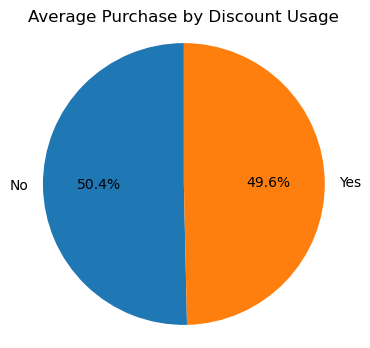

In [63]:
plt.figure(figsize=(4, 4))

plt.pie(discount_avg.values,labels=discount_avg.index,autopct='%1.1f%%',startangle=90)

plt.title("Average Purchase by Discount Usage")
plt.axis('equal')  # Keeps pie circular

plt.show()

##### *Conclusion*
Average purchases are nearly identical regardless of discount usage, with **non-users slightly higher (50.4%)** than users (49.6%).

### *4. Multivariate Analysis*

#### 1. Age Group + Gender → Average Purchase Amount :

In [64]:
age_gender_spend = df.groupby(['Age Group','Gender'])['Purchase Amount (USD)'].mean().unstack()
age_gender_spend

Gender,Female,Male
Age Group,,
16-30,62.152542,59.547401
31-50,58.527273,59.541837
51-65,61.500000,59.719687
66-80,58.788462,58.924303


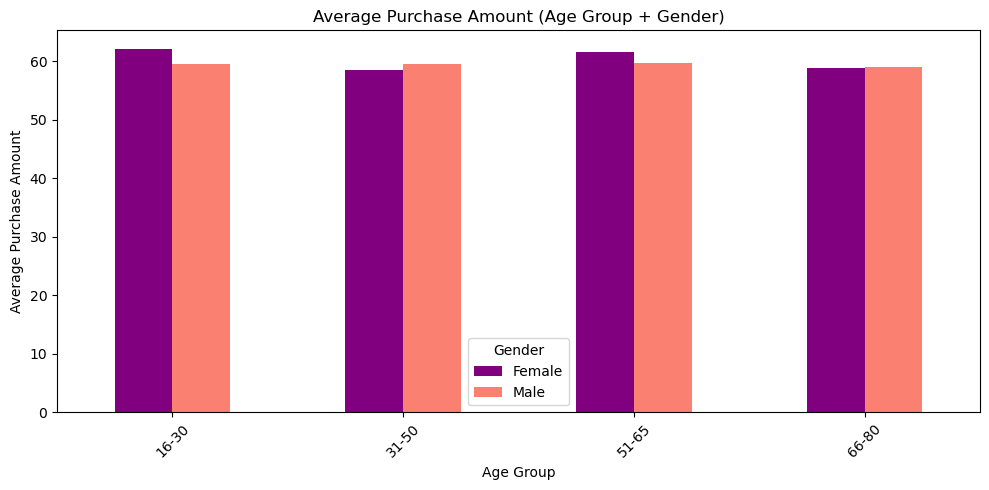

In [65]:
# Reset index to convert pivot table into DataFrame
age_gender_df = age_gender_spend.reset_index()

# Set index again for plotting
age_gender_spend.plot(kind='bar',figsize=(10,5),color=['purple', 'salmon'])  # Change colors here

plt.title("Average Purchase Amount (Age Group + Gender)")
plt.ylabel("Average Purchase Amount")
plt.xlabel("Age Group")
plt.xticks(rotation=45)
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

##### *Conclusion*
Average purchase amounts are similar across genders in all age groups, with **females slightly higher** in most groups **except ages 31–50** where **males** spend marginally more.

#### 2. Category + Season → Total Revenue :

In [66]:
category_season = df.groupby(['Category','Season'])['Purchase Amount (USD)'].sum().unstack()
category_season

Season,Fall,Spring,Summer,Winter
Category,,,,
Accessories,19874,17007,19028,18291
Clothing,26220,27692,23078,27274
Footwear,8665,9555,9393,8480
Outerwear,5259,4425,4278,4562


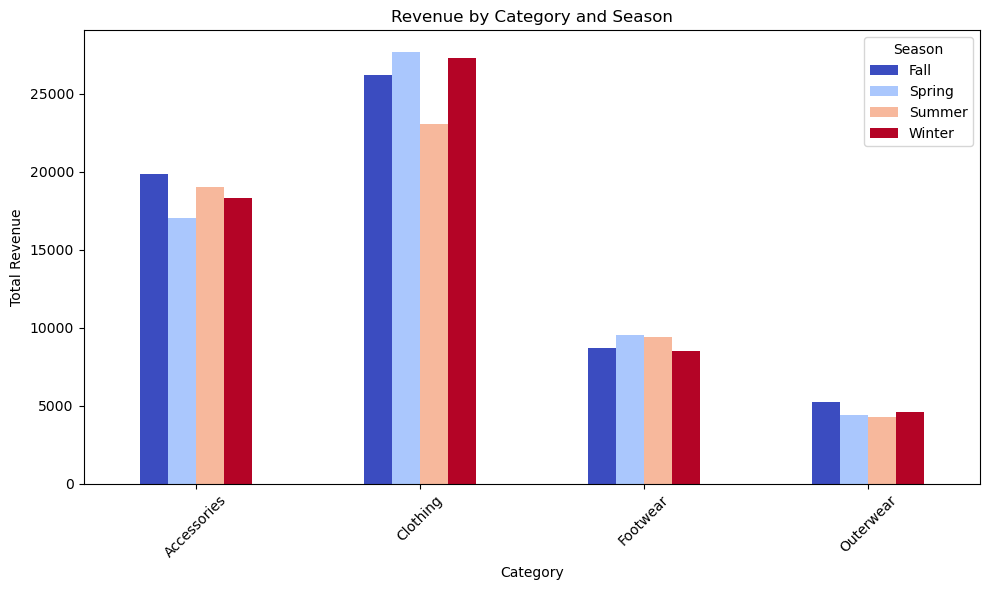

In [67]:
category_season.plot(kind='bar',figsize=(10,6),colormap='coolwarm')   # Matplotlib colormap

plt.title("Revenue by Category and Season")
plt.ylabel("Total Revenue")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.legend(title="Season")

plt.tight_layout()
plt.show()

##### *Conclusion*
**Clothing** generates the **highest revenue** across all seasons **(peaking in Spring)**, while **Outerwear** contributes the **least**, with overall revenues remaining relatively consistent seasonally.

#### 3. Category + Location → Total Revenue

In [68]:
category_location = df.pivot_table(values='Purchase Amount (USD)',index='Category',columns='Location',aggfunc='sum')
category_location

Location,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,Florida,Georgia,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
Category,,,,,,,,,,,,,,,,,,,,,
Accessories,1576,1719,1270,1555,1845,1454,1334,1486,1232,1389,...,1655,1863,1609,1307,1125,1584,1407,1907,1187,1388
Clothing,2334,2229,2129,2413,2740,1748,1905,2336,1680,2336,...,1698,1856,1817,2116,2426,2098,2155,1903,2157,1850
Footwear,914,693,471,589,662,654,589,769,434,827,...,492,709,853,794,942,939,716,781,732,703
Outerwear,437,226,456,271,358,366,398,167,452,93,...,391,344,433,226,367,221,345,583,120,368


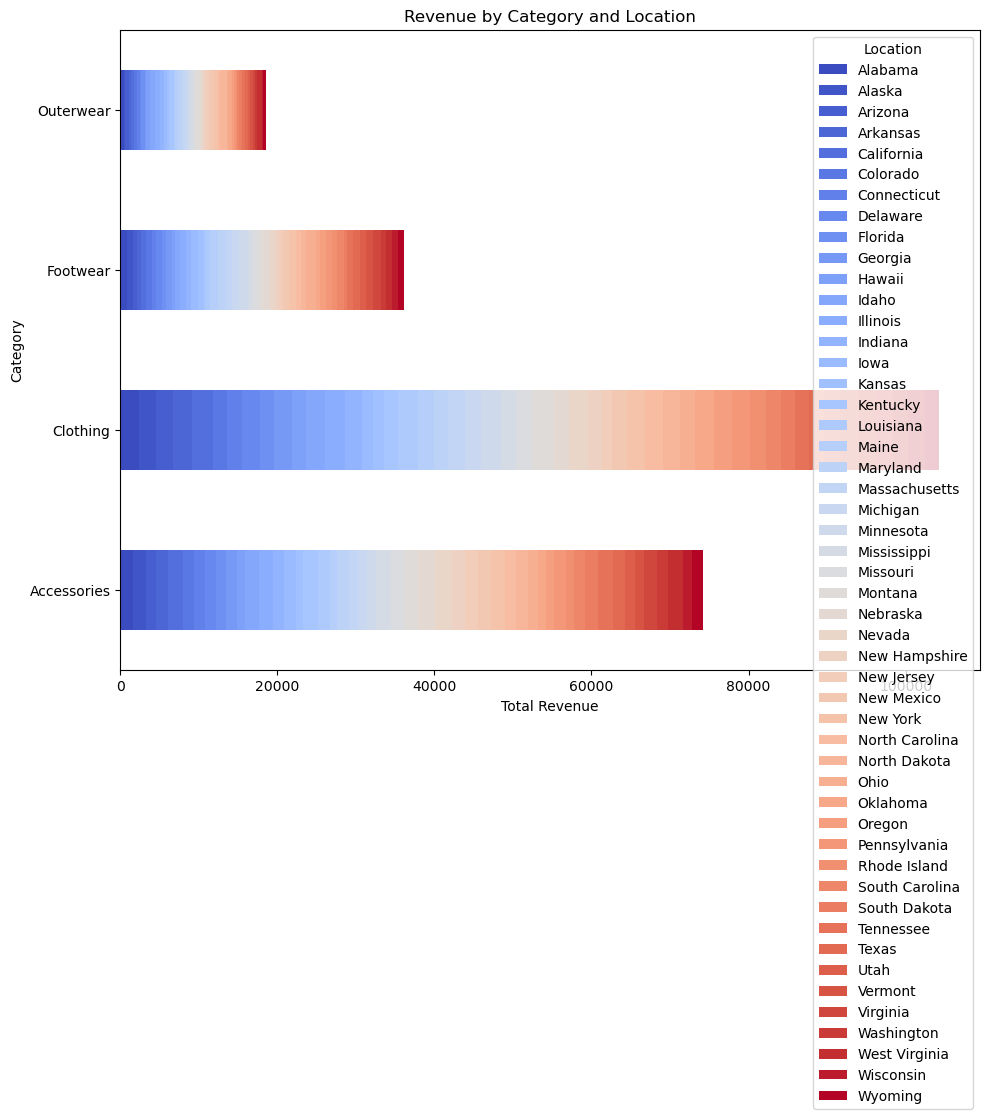

In [69]:

category_location.plot(kind='barh',stacked=True,figsize=(10,10),colormap='coolwarm')

plt.title("Revenue by Category and Location")
plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.legend(title="Location")

plt.tight_layout()
plt.show()

##### *Conclusion*
**Clothing** generates the **highest total revenue** across locations, followed by Accessories, while Footwear and Outerwear contribute comparatively lower revenues.

### *5. Pareto Analysis* : 
###### Pareto Analysis is a technique used to identify the few important factors that contribute to most of the results.It is based on the 80/20 Rule, which says: Around 80% of results come from 20% of causes.

##### A] Calculate Revenue by Category :

In [70]:
# Group revenue by category
category_revenue = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

# Convert to DataFrame
pareto_df = category_revenue.reset_index()  # onverts the grouped result into a proper table (DataFrame).
pareto_df.columns = ['Category', 'Total Revenue']

# Calculate cumulative percentage
pareto_df['Cumulative %'] = pareto_df['Total Revenue'].cumsum() / pareto_df['Total Revenue'].sum() * 100 # cumsum ->Adds revenue step-by-step (running total)

pareto_df

,Category,Total Revenue,Cumulative %
0,Clothing,104264,44.732947
1,Accessories,74200,76.567374
2,Footwear,36093,92.052548
3,Outerwear,18524,100.000000


##### B] Pareto Chart :

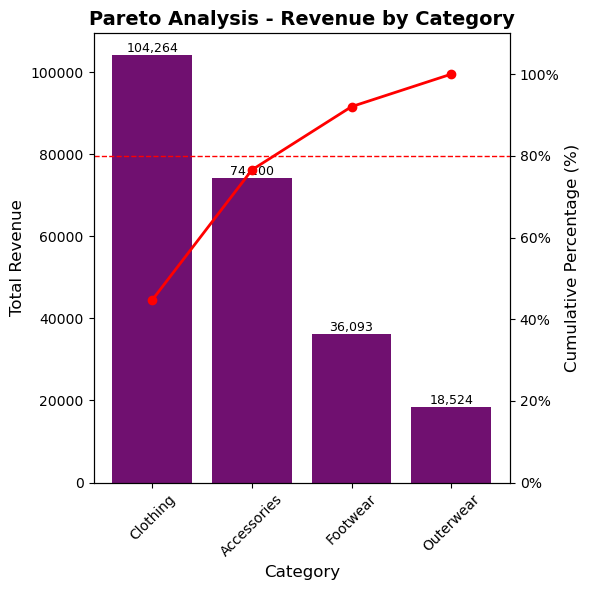

In [74]:
plt.figure(figsize=(6,6))    # Creates a square chart (6×6 size).

# Bar plot (Revenue)
ax1 = sns.barplot(x='Category',y='Total Revenue',data=pareto_df,color='purple')  # Creates purple bars showing Total Revenue for each Category

ax1.set_ylabel("Total Revenue", fontsize=12)  # Y-axis label (Revenue)
ax1.set_xlabel("Category", fontsize=12) # X-axis label (Category)
ax1.set_title("Pareto Analysis - Revenue by Category", fontsize=14, weight='bold') # Bold title
plt.xticks(rotation=45)  # Rotates category names 45° for readability

# Add value labels on bars
for i, v in enumerate(pareto_df['Total Revenue']):
    ax1.text(i, v, f"{v:,.0f}", ha='center', va='bottom', fontsize=9)   # Writes the exact revenue number on top of each bar.

# Secondary axis (Cumulative %)
ax2 = ax1.twinx()    # Adds a second Y-axis for cumulative percentage.
ax2.plot(pareto_df['Category'],pareto_df['Cumulative %'],color='red',marker='o',linewidth=2)  # Draws a line showing cumulative percentage contribution.

ax2.set_ylabel("Cumulative Percentage (%)", fontsize=12)
ax2.set_ylim(0, 110) #Adds label, Sets limit up to 110%

# Format right axis as percentage
ax2.yaxis.set_major_formatter(lambda x, pos: f'{int(x)}%') # Shows values as percentages

# Add 80% reference line
ax2.axhline(80, color='red', linestyle='--', linewidth=1) # Adds a red dashed line at 80% (Pareto Rule reference).

plt.tight_layout()
plt.show()

##### *Conclusion*
The Pareto analysis shows that **Clothing and Accessories** together contribute the **majority of total revenue**, accounting for around 80% of overall sales.
This indicates that focusing on these top two categories would have the greatest impact on revenue growth.

#### 6. Strategic Insights & Recommendations :

**1. Prioritize Core Revenue Drivers:**
Clothing and Accessories generate almost 80% of total revenue, so focus on adding more variety, managing stock better, and offering premium options in these categories to increase overall revenue.

**2. Strengthen Subscription Adoption:**
Since subscribers and non-subscribers spend nearly the same, make subscriptions more attractive with special benefits, loyalty rewards, and early access offers to improve customer retention rate.

**3. Optimize Discount Allocation:**
Discounts are not greatly increasing sales, so use targeted and personalized discounts, especially for low-performing categories like Outerwear, to protect profits and improve discount strategy.

**4. Leverage Seasonal & Category Trends:**
Plan marketing campaigns based on seasonal demand (Clothing performs well and Fall slightly leads revenue) to improve category-level performance and manage inventory better.

**5. Target High-Concentration Locations:**
Focus marketing and operational efforts in high-performing states to increase regional revenue growth.

**6. Increase AOV & Customer Satisfaction:**
Encourage customers to buy more through cross-selling and bundling (like Clothing + Accessories), and improve after-sales service to boost Average Order Value (AOV), customer satisfaction, and repeat purchases.

#### 7. Final Conclusion :

This Customer Shopping Trends Analysis used KPI Identification, Univariate, Bivariate, Multivariate, and Pareto Analysis to uncover key business insights. The findings highlight strong revenue concentration in Clothing and Accessories, stable purchasing behavior across gender and season, and opportunities to improve subscription adoption, discount allocation, customer retention rate, and overall revenue. Implementing data-driven, category-focused, and customer-centric strategies will support sustainable growth and long-term business performance.